# **Install Required Libraries**

In [5]:
# Installing required libraries
!pip -q install wordcloud
!pip -q install nltk
!pip -q install transformers
!pip -q install xgboost

# **Import Libraries**

In [6]:
# Importing required libraries
import warnings
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Downloading required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt")

# Configuring display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# **Download the Dataset**

In [7]:
# Load Dataset
df = pd.read_csv("/content/data.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


# **Initial Dataset Inspection**

In [8]:
# Dataset Inspection
print("Shape of Dataset:", df.shape)

print("\nColumn Names")
print(df.columns.tolist())

Shape of Dataset: (5842, 2)

Column Names
['Sentence', 'Sentiment']


In [9]:
print("\nFirst Five Records")
display(df.head())


First Five Records


,Sentence,Sentiment
0,"The GeoSolutions technology will leverage Benefon 's GPS solutions by providing Location Based Search Technology , a Communities Platform , location relevant multimedia content and a new and powerful commercial model .",positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real possibility",negative
2,"For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .",positive
3,"According to the Finnish-Russian Chamber of Commerce , all the major construction companies of Finland are operating in Russia .",neutral
4,"The Swedish buyout firm has sold its remaining 22.4 percent stake , almost eighteen months after taking the company public in Finland .",neutral


In [10]:
print("\nDataset Information")
df.info()


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5842 entries, 0 to 5841
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentence   5842 non-null   object
 1   Sentiment  5842 non-null   object
dtypes: object(2)
memory usage: 91.4+ KB


# **Data Quality Assessment**

In [11]:
# Missing Values and Duplicate Records
quality_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().sum() / len(df) * 100).round(2),
    "Data Type": df.dtypes
})

display(quality_summary)

print(f"\nTotal Duplicate Records : {df.duplicated().sum()}")

,Missing Values,Missing (%),Data Type
Sentence,0,0.0,object
Sentiment,0,0.0,object



Total Duplicate Records : 6


In [12]:
# Remove Duplicate Records
print(f"Dataset Shape Before Removing Duplicates : {df.shape}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataset Shape After Removing Duplicates  : {df.shape}")

print(f"Remaining Duplicate Records : {df.duplicated().sum()}")

Dataset Shape Before Removing Duplicates : (5842, 2)
Dataset Shape After Removing Duplicates  : (5836, 2)
Remaining Duplicate Records : 0


In [13]:
# Sentiment Distribution
sentiment_counts = df["Sentiment"].value_counts().sort_index()

sentiment_percentages = (
    df["Sentiment"]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

distribution_df = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage (%)": sentiment_percentages
})

display(distribution_df)

,Count,Percentage (%)
Sentiment,,
negative,860,14.74
neutral,3124,53.53
positive,1852,31.73


In [14]:
# Duplicate Sentence Analysis
duplicate_sentences = df["Sentence"].duplicated().sum()

print(f"Duplicate Sentences : {duplicate_sentences}")

Duplicate Sentences : 514


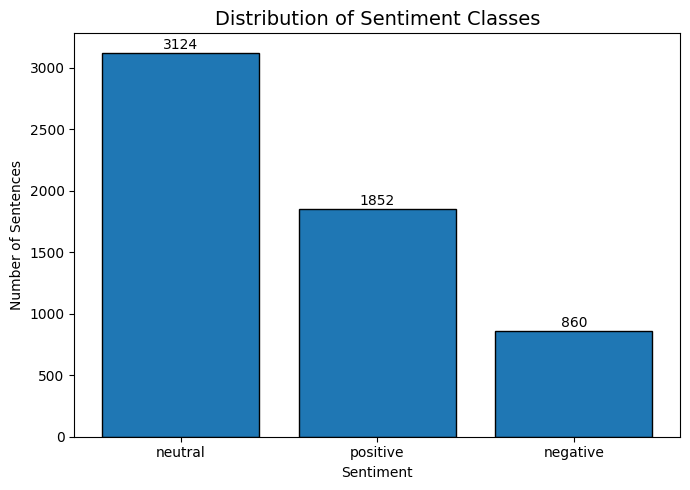

In [15]:
# Visualisation of Sentiment Distribution
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    edgecolor="black"
)

plt.title("Distribution of Sentiment Classes", fontsize=14)
plt.xlabel("Sentiment")
plt.ylabel("Number of Sentences")

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 30,
        f"{height}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [16]:
# Sentence Length Statistics
df["Word_Count"] = df["Sentence"].apply(lambda x: len(str(x).split()))

# Summary statistics
display(df["Word_Count"].describe().to_frame().T)

,count,mean,std,min,25%,50%,75%,max
Word_Count,5836.0,20.995888,10.291084,2.0,13.0,19.0,27.0,81.0


In [17]:
# Identify Very Short Sentences
short_sentences = df[df["Word_Count"] < 5]

print(f"Number of sentences with fewer than 5 words: {len(short_sentences)}")
print(f"Percentage of dataset: {(len(short_sentences)/len(df)*100):.2f}%")

display(short_sentences.head(10))

Number of sentences with fewer than 5 words: 54
Percentage of dataset: 0.93%


,Sentence,Sentiment,Word_Count
29,All are welcome .,neutral,4
90,$YANG Double bottom 5.2,positive,4
98,$TSLA recall,negative,2
157,R&D Loan ) .,neutral,4
209,Just went long $ILMN,positive,4
372,All rights reserved .,neutral,4
442,$DARA breaking out,positive,3
863,long $AAPL,positive,2
921,It 's not .,neutral,4
1352,$TSPT long 8.00,positive,3


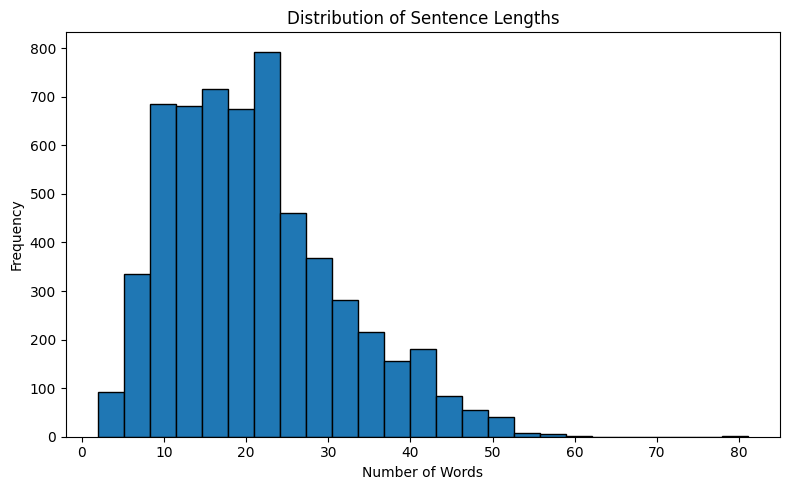

In [18]:
# Distribution of Sentence Lengths
plt.figure(figsize=(8,5))

plt.hist(
    df["Word_Count"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Sentence Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# **Exploratory Data Analysis (EDA)**

In [19]:
# Basic Text Cleaning for Exploratory Analysis

stop_words = set(stopwords.words("english"))

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return words

all_words = []

for sentence in df["Sentence"]:
    all_words.extend(basic_clean(sentence))

print(f"Total Words after Cleaning: {len(all_words)}")

Total Words after Cleaning: 65251


In [20]:
# Financial Vocabulary Analysis
word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(top_words)

,Word,Frequency
0,eur,1627
1,mn,815
2,company,807
3,profit,568
4,sales,560
5,finnish,527
6,said,516
7,net,499
8,million,494
9,operating,371


In [21]:
# Remove Domain-Specific High-Frequency Terms
financial_stopwords = {
    "company", "said", "eur", "mn", "mln",
    "year", "period", "quarter", "group",
    "oyj", "finland"
}

filtered_words = [
    word for word in all_words
    if word not in financial_stopwords
]

word_counts = Counter(filtered_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=["Word", "Frequency"]
)

display(top_words)

,Word,Frequency
0,profit,568
1,sales,560
2,finnish,527
3,net,499
4,million,494
5,operating,371
6,share,286
7,new,274
8,business,246
9,first,240


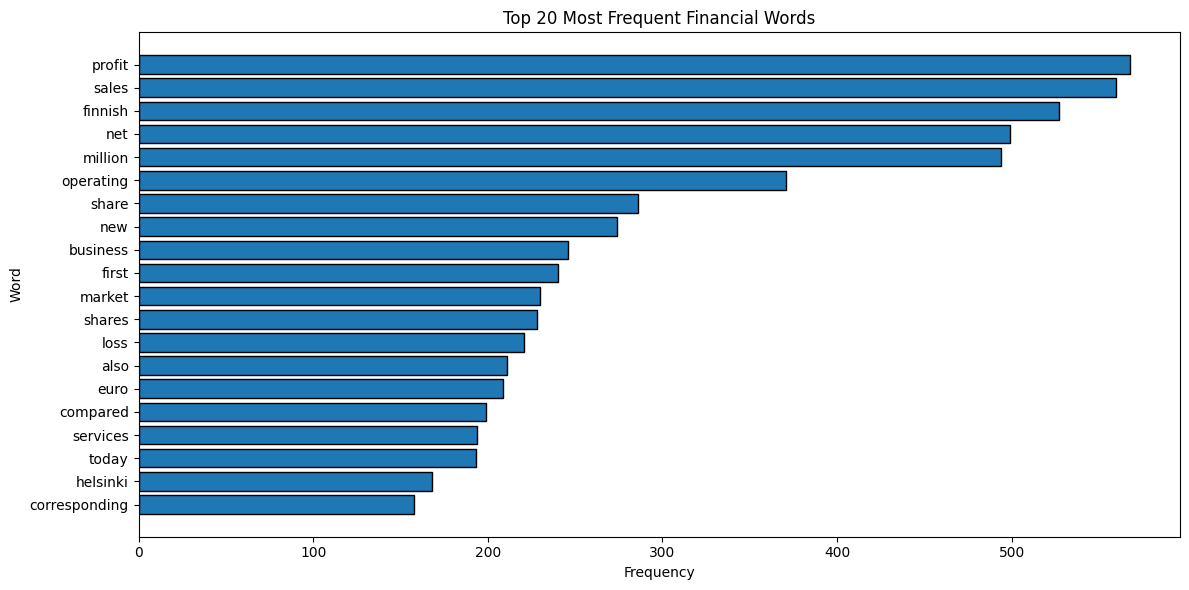

In [22]:
# Top 20 Most Frequent Financial Words

plt.figure(figsize=(12,6))

top_words_plot = top_words.sort_values("Frequency")

plt.barh(
    top_words_plot["Word"],
    top_words_plot["Frequency"],
    edgecolor="black"
)

plt.title("Top 20 Most Frequent Financial Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

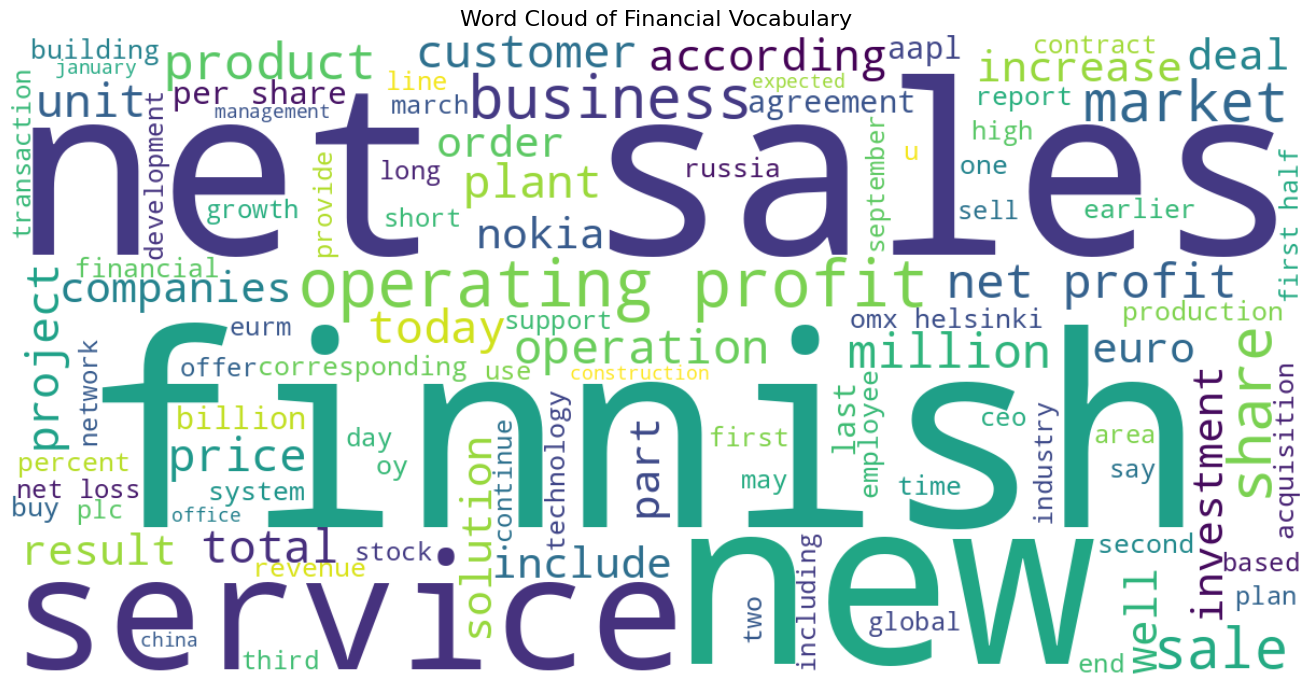

In [23]:
# Word Cloud of Financial Vocabulary
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100
).generate(" ".join(filtered_words))

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Financial Vocabulary", fontsize=16)

plt.tight_layout()
plt.show()

In [24]:
# Vocabulary Analysis by Sentiment Class
sentiments = ["positive", "neutral", "negative"]

for sentiment in sentiments:

    print("=" * 60)
    print(f"Top 15 Words - {sentiment.capitalize()} Sentiment")
    print("=" * 60)

    words = []

    sentiment_sentences = df[df["Sentiment"] == sentiment]["Sentence"]

    for sentence in sentiment_sentences:
        words.extend(basic_clean(sentence))

    words = [
        word for word in words
        if word not in financial_stopwords
    ]

    top_words = Counter(words).most_common(15)

    display(pd.DataFrame(top_words,
                         columns=["Word","Frequency"]))

Top 15 Words - Positive Sentiment


,Word,Frequency
0,sales,216
1,profit,202
2,net,197
3,finnish,177
4,million,164
5,operating,120
6,new,96
7,rose,92
8,increased,89
9,share,83


Top 15 Words - Neutral Sentiment


,Word,Frequency
0,finnish,261
1,million,251
2,sales,239
3,profit,212
4,net,202
5,shares,172
6,business,171
7,new,164
8,operating,162
9,share,155


Top 15 Words - Negative Sentiment


,Word,Frequency
0,profit,154
1,sales,105
2,net,100
3,finnish,89
4,operating,89
5,million,79
6,loss,70
7,compared,62
8,decreased,61
9,first,57


In [25]:
# Financial Bigram Analysis

# Create cleaned text for bigram analysis
cleaned_text = []

for sentence in df["Sentence"]:
    words = basic_clean(sentence)
    words = [word for word in words if word not in financial_stopwords]
    cleaned_text.append(" ".join(words))

# Extract bigrams
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=20
)

X = vectorizer.fit_transform(cleaned_text)

bigram_counts = X.sum(axis=0).A1

bigrams = pd.DataFrame({
    "Bigram": vectorizer.get_feature_names_out(),
    "Frequency": bigram_counts
})

bigrams = bigrams.sort_values(
    by="Frequency",
    ascending=False
)

display(bigrams)

,Bigram,Frequency
8,net sales,276
12,operating profit,238
7,net profit,127
13,per share,91
10,omx helsinki,73
6,net loss,64
3,first half,61
5,million usd,53
11,operating loss,49
18,stock exchange,46


# **Text Preprocessing**

In [26]:
# Text Preprocessing Function
lemmatizer = WordNetLemmatizer()

stop_words = set(stopwords.words("english"))

financial_stopwords = {
    "company",
    "said",
    "group",
    "oyj",
    "finland"
}
stop_words = stop_words.union(financial_stopwords)


def preprocess_text(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = text.replace("-", " ")

    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [27]:
# Apply Text Preprocessing
df["Cleaned_Sentence"] = df["Sentence"].apply(preprocess_text)

print("Text preprocessing completed successfully.")

Text preprocessing completed successfully.


In [28]:
# Original vs Cleaned Text
comparison = df[["Sentence", "Cleaned_Sentence"]].sample(
    10,
    random_state=38
)

display(comparison)

,Sentence,Cleaned_Sentence
194,Stora is due to release its fourth-quarter and 2009 full-year earnings on Feb. 4 .,stora due release fourth quarter 2009 full year earnings feb 4
4313,"$TSLA TO RECALL 2,700 MODEL X SUVS FOR SEAT-BELT FIX",tsla recall 2700 model x suvs seat belt fix
2496,UPDATE 1-Lloyds to cut 945 jobs as part of 3-year restructuring plan,update 1 lloyds cut 945 jobs part 3 year restructuring plan
4010,The front surfaces of these valve plates are directed towards each other .,front surfaces valve plates directed towards
1302,"In the Baltic countries , Atria 's target is organic growth .",baltic countries atria target organic growth
3149,Tullow Oil Suspends Dividend Amid Oil Price Fall,tullow oil suspends dividend amid oil price fall
5685,AstraZeneca suffers setback after drug fails to treat eye cancer,astrazeneca suffers setback drug fails treat eye cancer
179,"The government started the sell-off last month , putting an 8 percent stake in TeliaSonera on the auction bloc .",government started sell last month putting 8 percent stake teliasonera auction bloc
3096,AB InBev attacks SABMiller bid rebuffal,ab inbev attacks sabmiller bid rebuffal
2842,Randgold profit hit by poor gold price but dividend still increases,randgold profit hit poor gold price dividend still increases


# **Feature Engineering**

In [29]:
# Label Encoding

label_encoder = LabelEncoder()

df["Sentiment_Label"] = label_encoder.fit_transform(df["Sentiment"])

print("Label Mapping")

for label, value in zip(label_encoder.classes_,
                        label_encoder.transform(label_encoder.classes_)):
    print(f"{label:<10} --> {value}")

df[["Sentiment", "Sentiment_Label"]].head()

Label Mapping
negative   --> 0
neutral    --> 1
positive   --> 2


,Sentiment,Sentiment_Label
0,positive,2
1,negative,0
2,positive,2
3,neutral,1
4,neutral,1


In [30]:
# TF-IDF Vectorisation

tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    max_features=5000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X = tfidf.fit_transform(df["Cleaned_Sentence"])

y = df["Sentiment_Label"]

print("Feature Matrix Shape:", X.shape)
print("Number of Features:", len(tfidf.get_feature_names_out()))

Feature Matrix Shape: (5836, 5000)
Number of Features: 5000


In [31]:
# Train-Test Split


X_train, X_test, y_train, y_test, train_index, test_index = train_test_split(
    X,
    y,
    df.index,
    test_size=0.20,
    random_state=38,
    stratify=y
)
print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

print("\nFeature Dimensions")

print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training Samples : 4668
Testing Samples : 1168

Feature Dimensions
Training : (4668, 5000)
Testing : (1168, 5000)


# **Model Development and Evaluation**

In [32]:
# Model 1: Multinomial Naïve Bayes

# Train Multinomial Naïve Bayes Model

start_time = time.time()

nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train, y_train)

nb_training_time = time.time() - start_time

print("Multinomial Naïve Bayes model trained successfully.")
print(f"Training Time: {nb_training_time:.4f} seconds")

# Predict Test Data

nb_predictions = nb_model.predict(X_test)

print("Predictions generated successfully.")

Multinomial Naïve Bayes model trained successfully.
Training Time: 0.0138 seconds
Predictions generated successfully.


In [34]:
# Model Evaluation
nb_accuracy = accuracy_score(y_test, nb_predictions)

nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted"
)

print("Model Performance")

print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Model Performance
Accuracy : 0.6798
Precision: 0.6369
Recall   : 0.6798
F1 Score : 0.6388


In [35]:
# Classification Report


print(classification_report(
    y_test,
    nb_predictions,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

    negative       0.27      0.06      0.10       172
     neutral       0.68      0.90      0.77       625
    positive       0.74      0.60      0.66       371

    accuracy                           0.68      1168
   macro avg       0.56      0.52      0.51      1168
weighted avg       0.64      0.68      0.64      1168



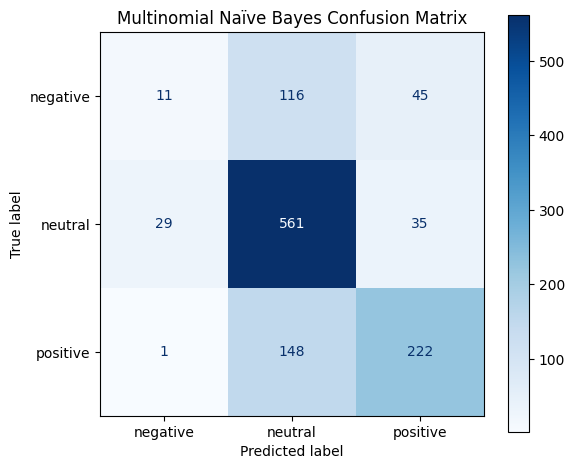

In [36]:
# Confusion Matrix


fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    display_labels=label_encoder.classes_,
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Multinomial Naïve Bayes Confusion Matrix")

plt.tight_layout()

plt.show()

In [37]:
# Store Model Performance

nb_results = {
    "Model": "Multinomial Naïve Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1,
    "Training Time": nb_training_time
}

In [38]:
# Model 2: Logistic Regression

# Hyperparameter Tuning for Logistic Regression

param_grid_lr = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 20],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

lr = LogisticRegression(

    random_state=38,

    max_iter=2000

)

grid_lr = GridSearchCV(

    estimator=lr,

    param_grid=param_grid_lr,

    cv=5,

    scoring="f1_weighted",

    n_jobs=-1

)

start_time = time.time()

grid_lr.fit(X_train, y_train)

lr_training_time = time.time() - start_time

lr_model = grid_lr.best_estimator_

print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_lr.best_score_,4))

print(f"\nTraining Time: {lr_training_time:.2f} seconds")

# Predict Test Data

lr_predictions = lr_model.predict(X_test)

print("Predictions generated successfully.")

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best Cross Validation Score:
0.6746

Training Time: 25.92 seconds
Predictions generated successfully.


In [40]:
# Model Evaluation

lr_accuracy = accuracy_score(

    y_test,

    lr_predictions

)

lr_precision = precision_score(

    y_test,

    lr_predictions,

    average="weighted"

)

lr_recall = recall_score(

    y_test,

    lr_predictions,

    average="weighted"

)

lr_f1 = f1_score(

    y_test,

    lr_predictions,

    average="weighted"

)

print("Model Performance")

print(f"Accuracy : {lr_accuracy:.4f}")

print(f"Precision: {lr_precision:.4f}")

print(f"Recall   : {lr_recall:.4f}")

print(f"F1 Score : {lr_f1:.4f}")

Model Performance
Accuracy : 0.6610
Precision: 0.6892
Recall   : 0.6610
F1 Score : 0.6716


In [41]:
# Classification Report


print(classification_report(

    y_test,

    lr_predictions,

    target_names=label_encoder.classes_

))

              precision    recall  f1-score   support

    negative       0.35      0.51      0.41       172
     neutral       0.76      0.70      0.73       625
    positive       0.72      0.66      0.69       371

    accuracy                           0.66      1168
   macro avg       0.61      0.63      0.61      1168
weighted avg       0.69      0.66      0.67      1168



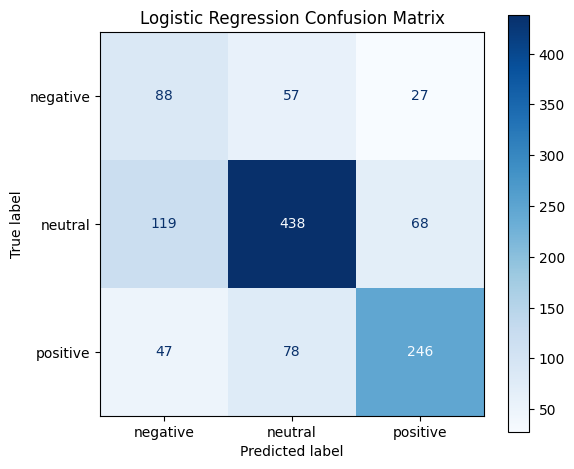

In [42]:
# Confusion Matrix


fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    lr_predictions,

    display_labels=label_encoder.classes_,

    cmap="Blues",

    values_format="d",

    ax=ax

)

ax.set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()

plt.show()

In [43]:
# Store Model Performance

lr_results = {

    "Model": "Logistic Regression",

    "Accuracy": lr_accuracy,

    "Precision": lr_precision,

    "Recall": lr_recall,

    "F1 Score": lr_f1,

    "Training Time": lr_training_time

}

In [44]:
# Model 3: Linear Support Vector Machine (Linear SVM)

# Hyperparameter Tuning for Linear SVM

param_grid_svm = {
    "C": [0.01, 0.1, 0.5, 1, 2, 5, 10, 20],
    "class_weight": [None, "balanced"]
}

svm = LinearSVC(

    random_state=38,

    max_iter=5000

)

grid_svm = GridSearchCV(

    estimator=svm,

    param_grid=param_grid_svm,

    cv=5,

    scoring="f1_weighted",

    n_jobs=-1

)

start_time = time.time()

grid_svm.fit(X_train, y_train)

svm_training_time = time.time() - start_time

svm_model = grid_svm.best_estimator_

print("Best Parameters:")
print(grid_svm.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_svm.best_score_,4))

print(f"\nTraining Time: {svm_training_time:.2f} seconds")

# Predict Test Data

svm_predictions = svm_model.predict(X_test)

print("Predictions generated successfully.")

Best Parameters:
{'C': 0.1, 'class_weight': 'balanced'}

Best Cross Validation Score:
0.6619

Training Time: 16.93 seconds
Predictions generated successfully.


In [45]:
# Model Evaluation

svm_accuracy = accuracy_score(

    y_test,

    svm_predictions

)

svm_precision = precision_score(

    y_test,

    svm_predictions,

    average="weighted"

)

svm_recall = recall_score(

    y_test,

    svm_predictions,

    average="weighted"

)

svm_f1 = f1_score(

    y_test,

    svm_predictions,

    average="weighted"

)

print("Model Performance")

print(f"Accuracy : {svm_accuracy:.4f}")

print(f"Precision: {svm_precision:.4f}")

print(f"Recall   : {svm_recall:.4f}")

print(f"F1 Score : {svm_f1:.4f}")

Model Performance
Accuracy : 0.6652
Precision: 0.6791
Recall   : 0.6652
F1 Score : 0.6667


In [46]:
# Classification Report


print(classification_report(

    y_test,

    svm_predictions,

    target_names=label_encoder.classes_

))

              precision    recall  f1-score   support

    negative       0.35      0.41      0.38       172
     neutral       0.71      0.78      0.75       625
    positive       0.78      0.58      0.67       371

    accuracy                           0.67      1168
   macro avg       0.61      0.59      0.60      1168
weighted avg       0.68      0.67      0.67      1168



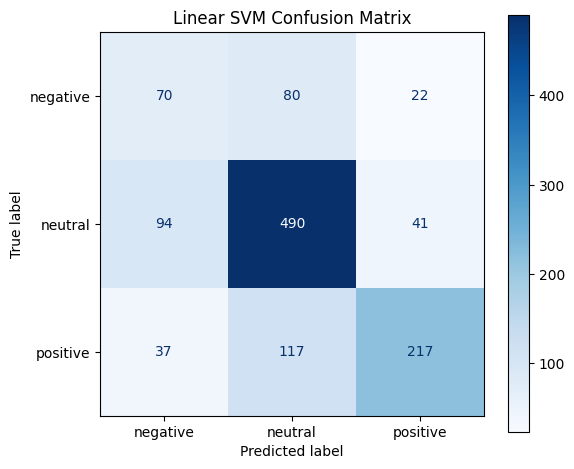

In [47]:
# Confusion Matrix


fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    svm_predictions,

    display_labels=label_encoder.classes_,

    cmap="Blues",

    values_format="d",

    ax=ax

)

ax.set_title("Linear SVM Confusion Matrix")

plt.tight_layout()

plt.show()

In [48]:
# Store Model Performance

svm_results = {

    "Model": "Linear SVM",

    "Accuracy": svm_accuracy,

    "Precision": svm_precision,

    "Recall": svm_recall,

    "F1 Score": svm_f1,

    "Training Time": svm_training_time

}

In [49]:
# Model 4: XGBoost

# Train XGBoost Model

start_time = time.time()

xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=150,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=38,
    eval_metric="mlogloss"
)

xgb_model.fit(X_train, y_train)

xgb_training_time = time.time() - start_time

print("XGBoost model trained successfully.")

print(f"Training Time: {xgb_training_time:.2f} seconds")

# Predict Test Data

xgb_predictions = xgb_model.predict(X_test)

print("Predictions generated successfully.")

XGBoost model trained successfully.
Training Time: 25.61 seconds
Predictions generated successfully.


In [51]:
# Model Evaluation
xgb_accuracy = accuracy_score(

    y_test,

    xgb_predictions

)

xgb_precision = precision_score(

    y_test,

    xgb_predictions,

    average="weighted"

)

xgb_recall = recall_score(

    y_test,

    xgb_predictions,

    average="weighted"

)

xgb_f1 = f1_score(

    y_test,

    xgb_predictions,

    average="weighted"

)

print("Model Performance")

print(f"Accuracy : {xgb_accuracy:.4f}")

print(f"Precision: {xgb_precision:.4f}")

print(f"Recall   : {xgb_recall:.4f}")

print(f"F1 Score : {xgb_f1:.4f}")

Model Performance
Accuracy : 0.6156
Precision: 0.6104
Recall   : 0.6156
F1 Score : 0.5567


In [52]:
# Classification Report


print(classification_report(

    y_test,

    xgb_predictions,

    target_names=label_encoder.classes_

))

              precision    recall  f1-score   support

    negative       0.27      0.06      0.10       172
     neutral       0.60      0.93      0.73       625
    positive       0.79      0.35      0.48       371

    accuracy                           0.62      1168
   macro avg       0.55      0.44      0.43      1168
weighted avg       0.61      0.62      0.56      1168



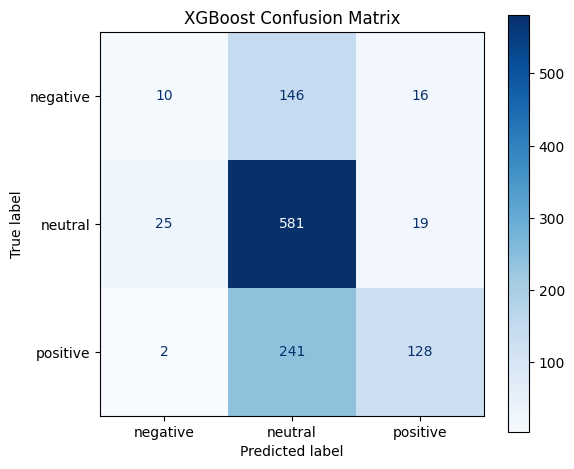

In [53]:
# Confusion Matrix


fig, ax = plt.subplots(figsize=(6,5))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    xgb_predictions,

    display_labels=label_encoder.classes_,

    cmap="Blues",

    values_format="d",

    ax=ax

)

ax.set_title("XGBoost Confusion Matrix")

plt.tight_layout()

plt.show()

In [54]:
# Store Model Performance

xgb_results = {

    "Model": "XGBoost",

    "Accuracy": xgb_accuracy,

    "Precision": xgb_precision,

    "Recall": xgb_recall,

    "F1 Score": xgb_f1,

    "Training Time": xgb_training_time

}

# **Model Comparison**

In [55]:
# Model Comparison
results_df = pd.DataFrame([

    nb_results,

    lr_results,

    svm_results,

    xgb_results

])

results_df = results_df.sort_values(

    by="F1 Score",

    ascending=False

).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Logistic Regression,0.660959,0.689196,0.660959,0.671608,25.915875
1,Linear SVM,0.665240,0.679113,0.665240,0.666726,16.925157
2,Multinomial Naïve Bayes,0.679795,0.636873,0.679795,0.638824,0.013804
3,XGBoost,0.615582,0.610405,0.615582,0.556693,25.614009


In [56]:
# Display Rounded Results

comparison_table = results_df.copy()

comparison_table["Accuracy"] = comparison_table["Accuracy"].round(4)
comparison_table["Precision"] = comparison_table["Precision"].round(4)
comparison_table["Recall"] = comparison_table["Recall"].round(4)
comparison_table["F1 Score"] = comparison_table["F1 Score"].round(4)
comparison_table["Training Time"] = comparison_table["Training Time"].round(2)

display(comparison_table)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time
0,Logistic Regression,0.6610,0.6892,0.6610,0.6716,25.92
1,Linear SVM,0.6652,0.6791,0.6652,0.6667,16.93
2,Multinomial Naïve Bayes,0.6798,0.6369,0.6798,0.6388,0.01
3,XGBoost,0.6156,0.6104,0.6156,0.5567,25.61


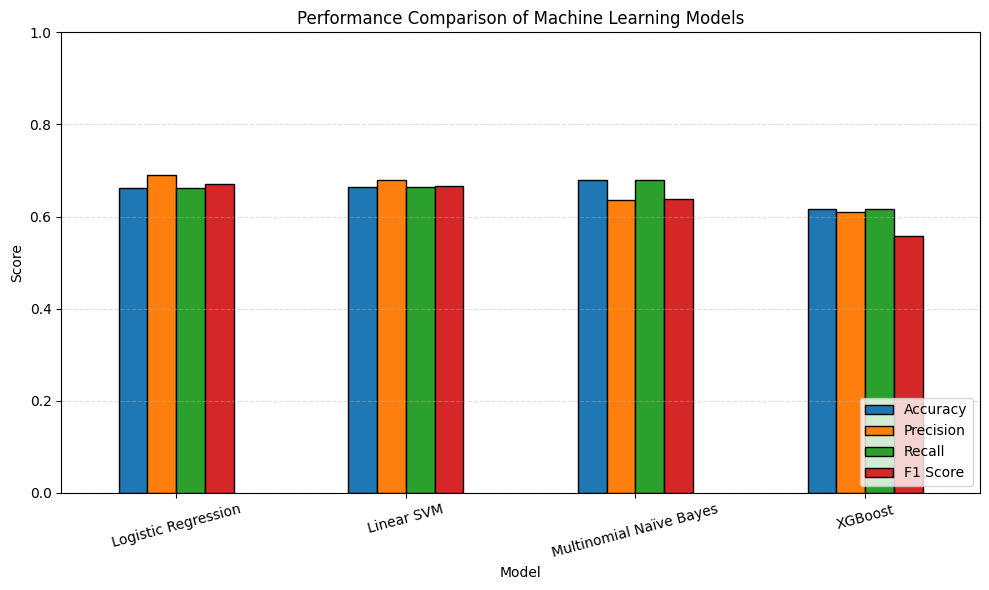

In [57]:
# Performance Comparison

metrics = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1 Score"

]

plot_df = comparison_table.set_index("Model")[metrics]

ax = plot_df.plot(

    kind="bar",

    figsize=(10,6),

    edgecolor="black"

)

plt.title("Performance Comparison of Machine Learning Models")

plt.ylabel("Score")

plt.xlabel("Model")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

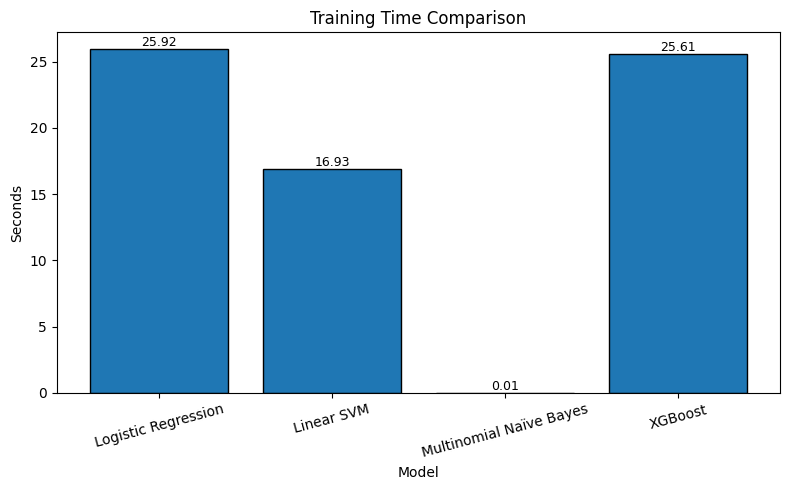

In [58]:
# Training Time Comparison

plt.figure(figsize=(8,5))

bars = plt.bar(

    comparison_table["Model"],

    comparison_table["Training Time"],

    edgecolor="black"

)

plt.title("Training Time Comparison")

plt.ylabel("Seconds")

plt.xlabel("Model")

plt.xticks(rotation=15)

for bar in bars:

    height = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        height,

        f"{height:.2f}",

        ha="center",

        va="bottom",

        fontsize=9

    )

plt.tight_layout()

plt.show()

In [59]:
# Best Performing Model

best_model = comparison_table.iloc[0]

print("Best Performing Model")

print("-" * 40)

print(f"Model          : {best_model['Model']}")

print(f"Accuracy       : {best_model['Accuracy']:.4f}")

print(f"Precision      : {best_model['Precision']:.4f}")

print(f"Recall         : {best_model['Recall']:.4f}")

print(f"F1 Score       : {best_model['F1 Score']:.4f}")

print(f"Training Time  : {best_model['Training Time']:.2f} seconds")

Best Performing Model
----------------------------------------
Model          : Logistic Regression
Accuracy       : 0.6610
Precision      : 0.6892
Recall         : 0.6610
F1 Score       : 0.6716
Training Time  : 25.92 seconds


## **Error Analysis**

In [60]:
# Error Analysis
prediction_dictionary = {

    "Multinomial Naïve Bayes": nb_predictions,

    "Logistic Regression": lr_predictions,

    "Linear SVM": svm_predictions,

    "XGBoost": xgb_predictions

}

best_predictions = prediction_dictionary[best_model["Model"]]

print(f"Error Analysis will be performed using: {best_model['Model']}")

Error Analysis will be performed using: Logistic Regression


In [61]:
# Create Prediction Results

results = pd.DataFrame({

    "Original Sentence": df.loc[test_index, "Sentence"].values,

    "Actual": label_encoder.inverse_transform(y_test),

    "Predicted": label_encoder.inverse_transform(best_predictions)

})

results["Correct Prediction"] = (

    results["Actual"] == results["Predicted"]

)

display(results.head())

,Original Sentence,Actual,Predicted,Correct Prediction
0,"Because the application can be considered as a hacking application , it is classified by F-Secure as riskware .",neutral,neutral,True
1,Feed companies Suomen Rehu and Raisio do no import GMO feed .,neutral,neutral,True
2,The first stage of the contract covers 133 stores and 600 cash registers .,neutral,neutral,True
3,"In January-November 2009 , the group 's sales totalled EUR 7,801.7 mn , which was a drop of 12.6 % from the same period of 2008 .",negative,negative,True
4,And that 's exactly what happened on a recent weekday when an East Haven baker was brought in to remind residents about the Easter tradition of making wheat and rice pies .,neutral,neutral,True


In [62]:
# Prediction Summary

total_samples = len(results)

correct_predictions = results["Correct Prediction"].sum()

incorrect_predictions = total_samples - correct_predictions

error_rate = incorrect_predictions / total_samples

print("Prediction Summary")

print("-" * 40)

print(f"Total Test Samples     : {total_samples}")

print(f"Correct Predictions    : {correct_predictions}")

print(f"Incorrect Predictions  : {incorrect_predictions}")

print(f"Error Rate             : {error_rate:.4f}")

Prediction Summary
----------------------------------------
Total Test Samples     : 1168
Correct Predictions    : 772
Incorrect Predictions  : 396
Error Rate             : 0.3390


In [63]:
# Misclassified Samples

misclassified = results[

    results["Correct Prediction"] == False

]

print("Number of Misclassified Samples:")

print(len(misclassified))

display(misclassified.head(20))

Number of Misclassified Samples:
396


,Original Sentence,Actual,Predicted,Correct Prediction
9,The majority of the company 's personnel in Finland is temporarily laid off from one to six weeks in the period from February to June 2009 period .,neutral,negative,False
10,Altogether Finnair has canceled over 500 flights because of the strike .,neutral,negative,False
13,Managing Director Kari Inkinen says that Sponda 's leasing operations developed highly favourably .,positive,neutral,False
15,$PRGN A bottom right here?,neutral,negative,False
16,"Of the price , Kesko 's share is 10 mln euro $ 15.5 mln and it will recognize a gain of 4.0 mln euro $ 6.2 mln on the disposal which will be included in the result for the second quarter of 2008 .",positive,neutral,False
18,"`` However , the rapidly increasing costs and the strengthening of the euro were challenging for the whole industry , and they impacted on our results . ''",negative,neutral,False
25,"Among other industrial stocks , Metso added 0.53 pct to 40.04 eur , Wartsila B was down 0.77 pct at 47.87 eur and Rautaruukki K was 1.08 pct lower at 37.56 eur .",neutral,negative,False
28,"The largest restructuring is planned for Italy , where negotiations on about 40 job cuts are to be initiated today , the company noted .",negative,neutral,False
29,"`` Adjustment to the fall in price level , in contrast , has been less effective .",neutral,negative,False
31,Earnings per share ( EPS ) amounted to a loss of EUR0 .05 .,neutral,negative,False


In [64]:
# Misclassification Analysis

misclassification_summary = (

    misclassified

    .groupby(["Actual", "Predicted"])

    .size()

    .reset_index(name="Count")

    .sort_values(

        by="Count",

        ascending=False

    )

)

display(misclassification_summary)

,Actual,Predicted,Count
2,neutral,negative,119
5,positive,neutral,78
3,neutral,positive,68
0,negative,neutral,57
4,positive,negative,47
1,negative,positive,27


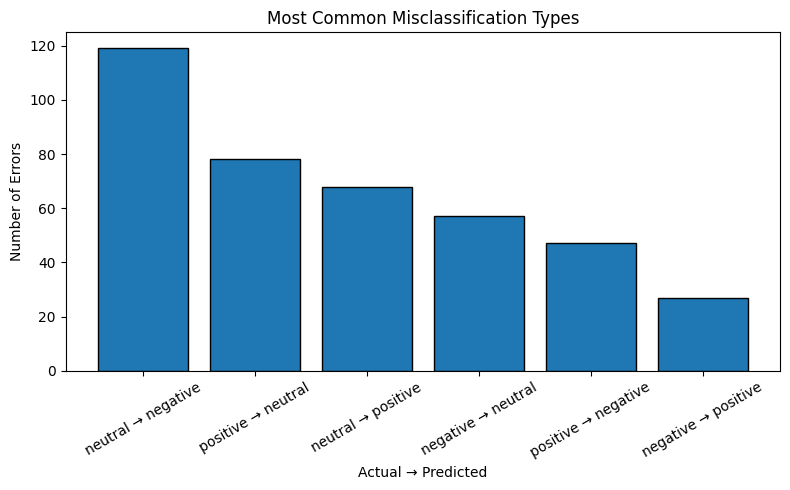

In [65]:
# Misclassification Pattern

plt.figure(figsize=(8,5))

plt.bar(

    misclassification_summary["Actual"] +

    " → " +

    misclassification_summary["Predicted"],

    misclassification_summary["Count"],

    edgecolor="black"

)

plt.title("Most Common Misclassification Types")

plt.xlabel("Actual → Predicted")

plt.ylabel("Number of Errors")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

In [66]:
# Most Frequent Error

most_common_error = misclassification_summary.iloc[0]

print("Most Frequent Misclassification")

print("-" * 40)

print(

    f"Actual Class    : {most_common_error['Actual']}"

)

print(

    f"Predicted Class : {most_common_error['Predicted']}"

)

print(

    f"Occurrences     : {most_common_error['Count']}"

)

Most Frequent Misclassification
----------------------------------------
Actual Class    : neutral
Predicted Class : negative
Occurrences     : 119
